<a href="https://colab.research.google.com/github/abhavanasaraswathi/Salary-prediction-/blob/main/iris_flower_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,accuracy_score

In [14]:
df = pd.read_csv("/iris_three_flower_classes.csv")

In [15]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
df. tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


EDA

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [18]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [19]:
print("number of rows are:",df.shape[0])
print("Number colums are:",df.shape[1])

number of rows are: 150
Number colums are: 5


In [20]:
X = df[ ["sepal_length","sepal_width", "petal_length", "petal_width"]]

y = df["species"]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=200)


logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)


logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 1.0


In [26]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)


y_pred_tree = tree_model.predict(X_test)


tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      tree_accuracy)

Decision Tree Accuracy: 1.0


In [27]:
print("Model Accuracy Comparison")
print("-------------------------")

print("Logistic Regression:",
      logistic_accuracy)

print("Decision Tree:",
      tree_accuracy)

Model Accuracy Comparison
-------------------------
Logistic Regression: 1.0
Decision Tree: 1.0


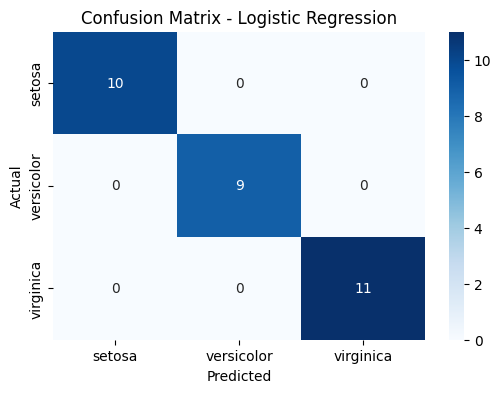

In [29]:
from sklearn.metrics import confusion_matrix

# Get unique target labels from your dataset
labels = df['species'].unique()

# Generate the confusion matrix
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=labels
)

# Plot the confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

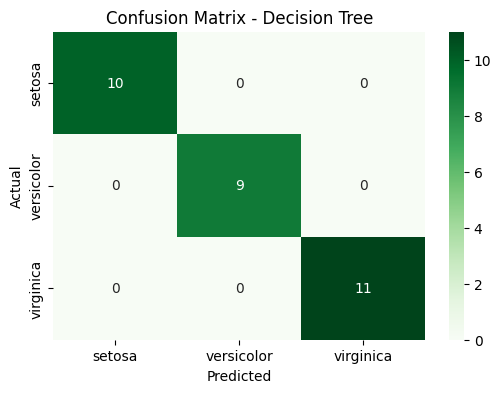

In [31]:
# Get unique target labels from your dataset
labels = df['species'].unique()

# Generate the confusion matrix for Decision Tree
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=labels
)

# Plot the confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()